# PPIC PPI subgraphs with PTM-aware nodes

Per **condition**, takes **top K genes** by max site-level |Log2FC × (−log10 p)|, builds the **induced subgraph** from **`data/ppic/edges.tsv`**, keeps the **largest connected component**, caps to **M** nodes by degree, lays out with **spring** layout. **Node color** = max |score| in that condition; **node size** = literature phospho row count from `ptm.txt` for that gene.

**Inputs:** `data.tsv`, `data/ppic/edges.tsv`, `data/ptm.txt`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root() -> Path:
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "data.tsv").is_file() and (p / "analyze" / "_conditions.py").is_file():
            return p
    raise FileNotFoundError("Project root not found (need data.tsv + analyze/_conditions.py).")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "analyze"))
from _conditions import CONDITIONS  # noqa: E402
import ptm_data as ptm  # noqa: E402

DATA_PATH = ROOT / "data.tsv"
PTM_PATH = ROOT / "data" / "ptm.txt"
PPIC_PATH = ROOT / "data" / "ppic" / "edges.tsv"
KSEA_LONG = ROOT / "output" / "analyze" / "ksea_prerank_long.tsv"

THR = float(-np.log10(0.05))
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 40)

print("ROOT =", ROOT)

import networkx as nx


ROOT = /Users/ph/Documents/phospho_mhg_anno


In [2]:
DATA = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
edges = pd.read_csv(PPIC_PATH, sep='\t', dtype=str)
edges['source'] = edges['source'].str.upper()
edges['target'] = edges['target'].str.upper()
df_ptm = ptm.load_ptm(PTM_PATH)
df_phos = ptm.filter_human(ptm.filter_ptm_type(df_ptm, 'PHOSPHORYLATION'))
pho_n = df_phos['substrate_genename'].astype(str).str.upper().value_counts()
print('PPIC edges:', len(edges))


PPIC edges: 298872


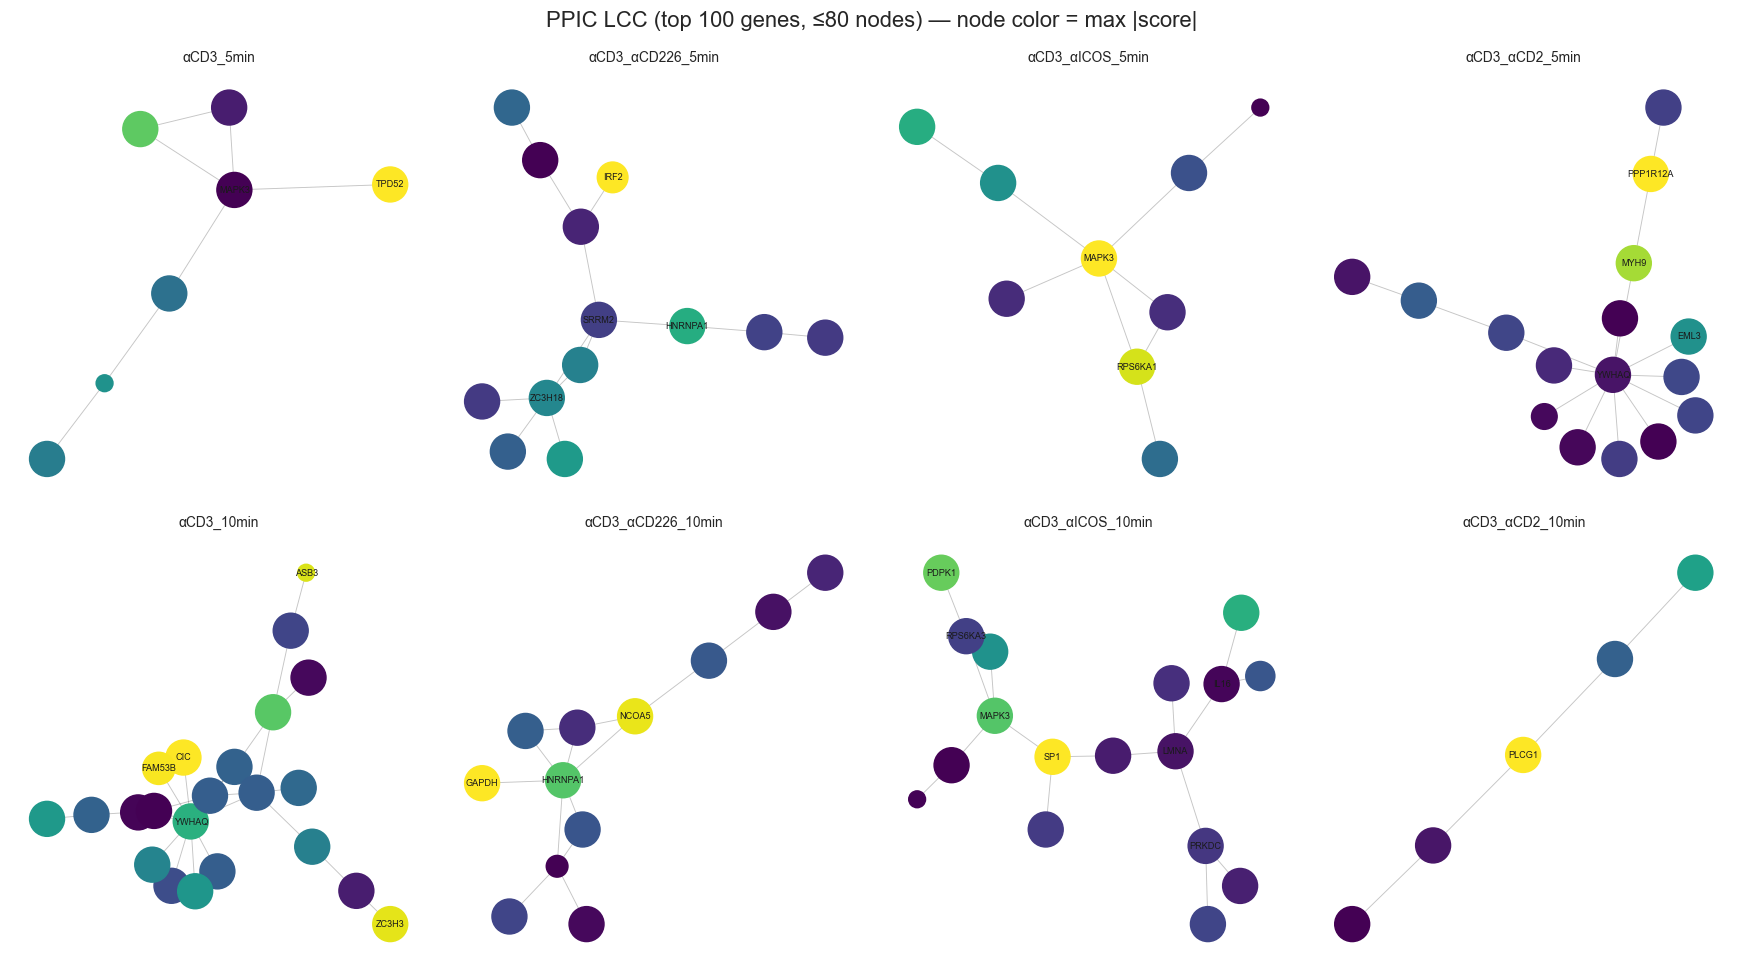

In [7]:
TOP_K = 100
MAX_NODES = 80
SEED = 42

def top_genes_one_condition(df, cond, k):
    log2 = pd.to_numeric(df[cond.log2fc_col], errors='coerce')
    nlp = pd.to_numeric(df[cond.neglogp_col], errors='coerce')
    sc = (log2 * nlp).abs()
    tmp = df.assign(_s=sc, _g=df['geneid'].astype(str).str.upper())
    gg = tmp.groupby('_g', sort=False)['_s'].max().sort_values(ascending=False)
    return list(gg.head(k).index)

def induced_subgraph(genes: set[str], edf: pd.DataFrame) -> nx.Graph:
    G = nx.Graph()
    G.add_nodes_from(genes)
    for a, b in zip(edf['source'], edf['target']):
        if a in genes and b in genes:
            G.add_edge(a, b)
    return G

def prune_lcc_deg(G: nx.Graph, max_nodes: int) -> nx.Graph:
    if G.number_of_nodes() == 0:
        return G
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    H = G.subgraph(comps[0]).copy()
    if H.number_of_nodes() <= max_nodes:
        return H
    deg = dict(H.degree())
    keep = set(sorted(deg, key=lambda n: deg[n], reverse=True)[:max_nodes])
    return H.subgraph(keep).copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.ravel()
for ax, cond in zip(axes, CONDITIONS):
    genes = set(top_genes_one_condition(DATA, cond, TOP_K))
    G0 = induced_subgraph(genes, edges)
    H = prune_lcc_deg(G0, MAX_NODES)
    if H.number_of_nodes() == 0:
        ax.set_title(cond.condition_id + ' (empty)')
        ax.axis('off')
        continue
    log2 = pd.to_numeric(DATA[cond.log2fc_col], errors='coerce')
    nlp = pd.to_numeric(DATA[cond.neglogp_col], errors='coerce')
    sc = (log2 * nlp).abs()
    gs = DATA.assign(_g=DATA['geneid'].astype(str).str.upper(), _sc=sc)
    score_by = gs.groupby('_g')['_sc'].max()
    vals = {n: float(score_by.get(n, 0.0)) for n in H.nodes()}
    sizes = {n: 120 + 40 * min(10, int(pho_n.get(n, 0))) for n in H.nodes()}
    pos = nx.spring_layout(H, seed=SEED, k=0.35 / max(1, np.sqrt(H.number_of_nodes())))
    nodelist = list(H.nodes())
    c = [vals[n] for n in nodelist]
    s = [sizes[n] for n in nodelist]
    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.25, width=0.6)
    nx.draw_networkx_nodes(H, pos, ax=ax, node_size=s, node_color=c, cmap='viridis')
    thr_lab = np.quantile([vals[n] for n in nodelist], 0.85) if nodelist else 0
    labels = {n: n for n in nodelist if vals[n] >= thr_lab or H.degree[n] >= max(3, max(dict(H.degree()).values()) - 1)}
    nx.draw_networkx_labels(H, pos, labels=labels, ax=ax, font_size=6)
    ax.set_title(cond.condition_id, fontsize=9)
    ax.axis('off')
fig.suptitle(f'PPIC LCC (top {TOP_K} genes, ≤{MAX_NODES} nodes) — node color = max |score|')
fig.tight_layout()
plt.show()
